В данном примере наш фильтр нижних частот представляет собой массив 5 × 5 со всеми единицами и усреднением.
Примените свертку между исходным изображением и ядром с помощью функции cv2.filter2D().

In [2]:
import numpy as np
import cv2
from pandas.io.formats import css

# чтение изображения
img_src = cv2.imread(r'static\1b\sample.jpg')

# подготовка фильтра в виде матрицы 5х5
kernel = np.array([[1, 1, 1, 1, 1],
                   [1, 1, 1, 1, 1],
                   [1, 1, 1, 1, 1],
                   [1, 1, 1, 1, 1],
                   [1, 1, 1, 1, 1]])
kernel = kernel/(np.sum(kernel) if np.sum(kernel)!=0 else 1) # нормализация ядра

#фильтрация исходного изображения
img_rst = cv2.filter2D(img_src,-1,kernel)

#сохранение конечного изображения
cv2.imwrite(r'static\output\1b\result1.jpg',img_rst)

True

В этом примере фильтр верхних частот представляет собой массив 3 × 3, который является переменной ядра в приведенной ниже программе.
Примените свертку между исходным изображением и ядром с помощью функции cv2.filter2D()

In [3]:
import numpy as np
import cv2

# чтение изображения
img_src = cv2.imread(r'static\1b\sample.jpg')

# подготовка фильтра в виде матрицы 3х3
kernel = np.array([[0.0, -1.0, 0.0],
 [-1.0, 4.0, -1.0],
 [0.0, -1.0, 0.0]])

kernel = kernel/(np.sum(kernel) if np.sum(kernel)!=0 else 1)

#фильтрация исходного изображения
img_rst = cv2.filter2D(img_src,-1,kernel)

#сохранение конечного изображения
cv2.imwrite(r'static\output\1b\result2.jpg',img_rst)

True

Выходное изображение выглядит так, как будто вся зернистая информация сохранена, а остальная часть исчезла.
Если вы измените массив ядра на следующий, информация о цвете будет сохранена с выделенными высокочастотными пиксельными областями:


In [4]:
import numpy as np
import cv2

# чтение изображения
img_src = cv2.imread(r'static\1b\sample.jpg')

kernel = np.array([[0.0, -1.0, 0.0],
 [-1.0, 5.0, -1.0],
 [0.0, -1.0, 0.0]])

kernel = kernel/(np.sum(kernel) if np.sum(kernel)!=0 else 1)

#фильтрация исходного изображения
img_rst = cv2.filter2D(img_src,-1,kernel)

#сохранение конечного изображения
cv2.imwrite(r'static\output\1b\result3.jpg',img_rst)

True

В этом примере мы определим собственное ядро для более чёткого выявления горизонтальных линий на растре.

In [6]:
import numpy as np
import cv2

# чтение изображения
img_src = cv2.imread(r'static\1b\sample.jpg')

# подготовка фильтра в виде матрицы 3х2
kernel = np.array([[-1.0, -1.0],
                   [2.0, 2.0],
                   [-1.0, -1.0]])

kernel = kernel/(np.sum(kernel) if np.sum(kernel)!=0 else 1)

#фильтрация исходного изображения
img_rst = cv2.filter2D(img_src,-1,kernel)

#сохранение конечного изображения
cv2.imwrite(r'static\output\1b\result4.jpg',img_rst)

True

## Задачи работы:
1. Применить ко всем растрам из папки «Изображения» фильтры высоких и низких частот. Сохранить обработанные изображения
2. Сравнить полученные изображения с исходными и составить описание (до-после). Указать, какие классы объектов стали наиболее ярко выражены. Сделать общий вывод о том, для каких целей лучше всего использовать фильтры высоких и низких частот
3. Определить свои параметры ядра (задать матрицу со своими параметрами) и указать, для каких целей его можно использовать. Привести примеры. Изображения, для обработки по Вашим параметрам можно выбирать любые, по желанию.
4. Оформить всё вышеописанное в виде отчета

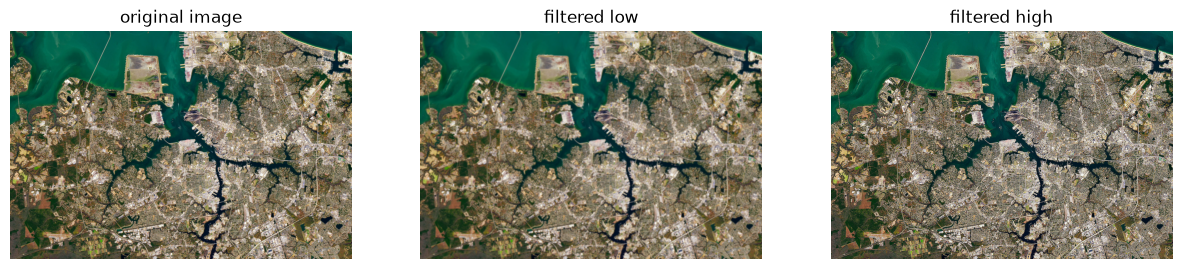

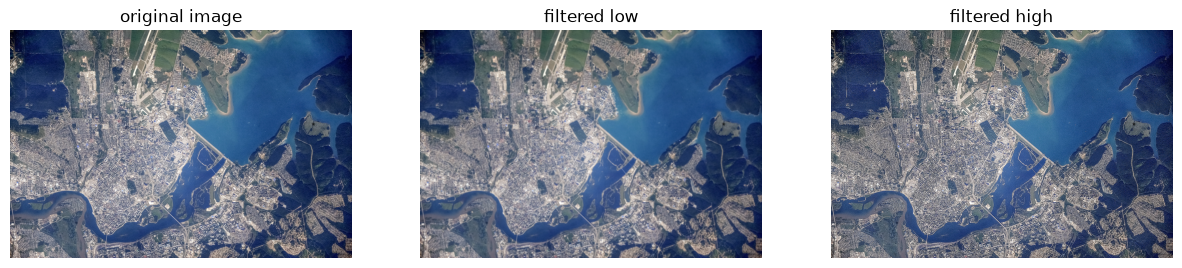

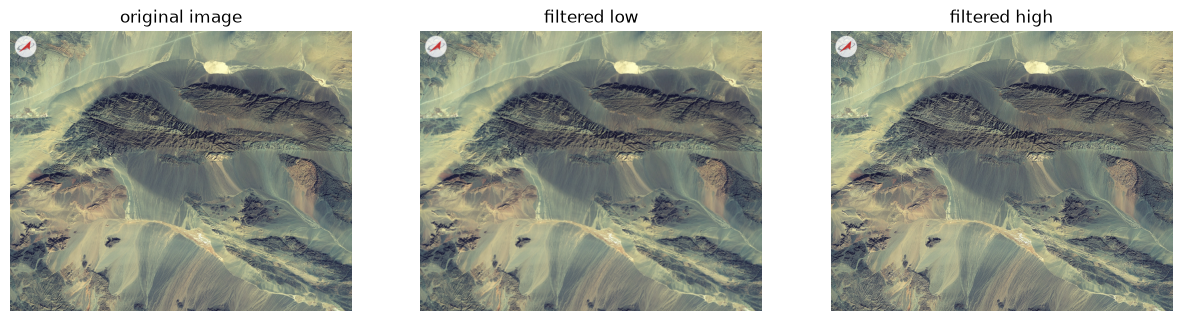

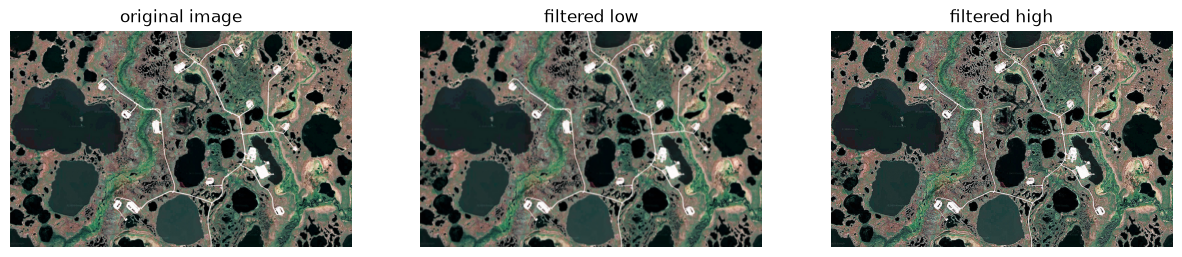

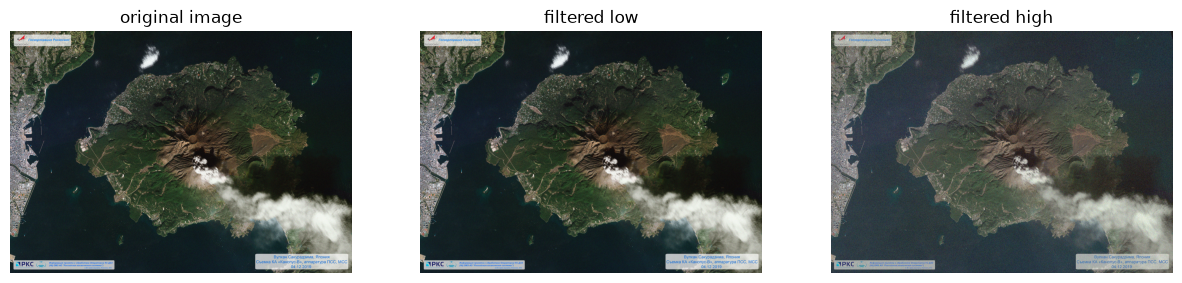

In [19]:
import matplotlib.pyplot as plt
import cv2


def apply_kernel(img, kernel):
    kernel = kernel / (np.sum(kernel) if np.sum(kernel) != 0 else 1)
    img_rst = cv2.filter2D(img, -1, kernel)
    return img_rst


def filter_low(img):
    kernel = np.array([[1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1],
                       [1, 1, 1, 1, 1]])
    return apply_kernel(img, kernel)


def filter_high(img):
    kernel = np.array([[0.0, -1.0, 0.0],
                       [-1.0, 5.0, -1.0],
                       [0.0, -1.0, 0.0]])
    return apply_kernel(img, kernel)


def filter_me(img):
    kernel = np.array([[-0.5, -1.0, -0.5],
                       [-1.0, 7.0, -1.0],
                       [-0.5, -1.0, -0.5]])
    return apply_kernel(img, kernel)


def process_image(dir, name):
    img = cv2.imread(dir + name)

    img_filtered_low = filter_low(img)
    cv2.imwrite(f'static\\output\\1b\\filtered_low_{name}', img_filtered_low)

    img_filtered_high = filter_high(img)
    cv2.imwrite(f'static\\output\\1b\\filtered_high_{name}', img_filtered_high)

    img_filtered_me = filter_me(img)
    cv2.imwrite(f'static\\output\\1b\\filtered_me_{name}', img_filtered_me)

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.axis('off')
    plt.title('original image')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.subplot(1,3,2)
    plt.axis('off')
    plt.imshow(cv2.cvtColor(img_filtered_low, cv2.COLOR_BGR2RGB))
    plt.title('filtered low')
    plt.subplot(1,3,3)
    plt.axis('off')
    plt.imshow(cv2.cvtColor(img_filtered_high, cv2.COLOR_BGR2RGB))
    plt.title('filtered high')
    plt.show()

path_dir = "static\\1b\\"
for name in ['1.JPG','2.jpg', '3.jpg', '4.jpg', '5.JPG']:
    process_image(path_dir, name)